# Section 1 - EDA (Exploratory Data Analysis)

## Objectif

Prédire si un **SKU (Stock Keeping Unit)** connaîtra une **rupture de stock** au cours des **3 prochains jours**.

L'objectif est d'anticiper les ruptures afin de permettre aux équipes d'approvisionnement et de logistique de prendre des mesures préventives, comme le réapprovisionnement des stocks ou l'ajustement des prévisions de demande.

## Contrainte métier

Ne pas détecter une rupture de stock future (**faux négatif**) est plus coûteux pour l'entreprise que prédire à tort une rupture (**faux positif**).

En effet, une rupture de stock peut entraîner :
- des pertes de ventes ;
- une diminution de la satisfaction et de la fidélité des clients ;
- des perturbations de la chaîne d'approvisionnement ;
- des coûts opérationnels supplémentaires.

À l'inverse, un faux positif conduit généralement à un réapprovisionnement anticipé ou à une vérification supplémentaire, dont l'impact est souvent moins important.

Par conséquent, l'évaluation des modèles privilégiera **le rappel (Recall)** afin de maximiser la détection des ruptures de stock, tout en surveillant également **la précision (Precision)** et le **score F1** afin de maintenir un équilibre entre les performances du modèle.

### Importation des bibliotheques

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

DATA_PATH = "../stocks.csv"


## A. Dataset Overview

Chargement brut, sans transformation, pour observer l'état natif du fichier avant toute décision de nettoyage.


In [ ]:
# Chargement du dataset
df = pd.read_csv(DATA_PATH)

# Vérification du nombre d'observations (20 SKUs × 5 magasins × 365 jours = 36 500 lignes).
print("Shape :", df.shape)

# Aperçu des premières observations.
df.head()

Shape: (36500, 10)


,date,sku_id,store_id,sales_qty,stock_level,promotion_flag,temperature,day_of_week,stockout_next_3d,stock_risk_score
0,2024-01-01,SKU_001,STORE_1,25.0,111,0,3.9,0,0,-0.003
1,2024-01-01,SKU_001,STORE_2,29.0,78,0,18.2,0,0,-0.011
2,2024-01-01,SKU_001,STORE_3,24.0,84,0,9.2,0,0,0.018
3,2024-01-01,SKU_001,STORE_4,29.0,98,0,9.7,0,0,-0.002
4,2024-01-01,SKU_001,STORE_5,33.0,4,0,9.6,0,1,0.991


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36500 entries, 0 to 36499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              36500 non-null  str    
 1   sku_id            36500 non-null  str    
 2   store_id          36500 non-null  str    
 3   sales_qty         34675 non-null  float64
 4   stock_level       36500 non-null  int64  
 5   promotion_flag    36500 non-null  int64  
 6   temperature       34675 non-null  float64
 7   day_of_week       36500 non-null  int64  
 8   stockout_next_3d  36500 non-null  int64  
 9   stock_risk_score  36500 non-null  float64
dtypes: float64(3), int64(4), str(3)
memory usage: 2.8 MB


In [46]:
# describe() sur les colonnes numériques : sert ici uniquement à repérer des ordres de grandeur
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,36500,365,2024-01-01,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku_id,36500,20,SKU_001,1825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_id,36500,5,STORE_1,7300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_qty,34675.0,NaN,NaN,NaN,31.037462,7.240304,9.0,26.0,30.0,36.0,65.0
stock_level,36500.0,NaN,NaN,NaN,74.977068,53.063276,0.0,26.0,73.0,121.0,185.0
promotion_flag,36500.0,NaN,NaN,NaN,0.152575,0.359583,0.0,0.0,0.0,0.0,1.0
temperature,34675.0,NaN,NaN,NaN,15.129915,10.021749,-25.5,8.4,15.1,21.9,63.0
day_of_week,36500.0,NaN,NaN,NaN,2.991781,2.003432,0.0,1.0,3.0,5.0,6.0
stockout_next_3d,36500.0,NaN,NaN,NaN,0.143151,0.350231,0.0,0.0,0.0,0.0,1.0
stock_risk_score,36500.0,NaN,NaN,NaN,0.141656,0.346823,-0.037,-0.006,0.002,0.011,1.028


**Observation :** la comparaison entre le shape obtenu et le shape attendu (36 500 lignes) et les types de colonnes (`date` probablement en `object` et non `datetime64`) orientent déjà les premières corrections de la section suivante.

## B. Data Quality Assessment

On vérifie ici uniquement les anomalies qui ont un impact direct sur l'entraînement de notre modèle avenir : valeurs manquantes (imputation ou suppression), doublons (fuite de données via duplication), types incorrects (`date` doit être temporel pour un split chronologique), et valeurs hors domaine métier plausible.

In [47]:
# --- Valeurs manquantes ---
# Objectif : décider imputation vs suppression. Une variable avec >30-40% de NaN
# devient un candidat à l'exclusion plutôt qu'à l'imputation (risque d'introduire du bruit).
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing_report


,missing_count,missing_pct
sales_qty,1825,5.0
temperature,1825,5.0


In [48]:
# --- Doublons au grain (date, sku_id, store_id) ---
# Ce grain doit être unique : un doublon signifierait deux observations pour la même
# combinaison jour/produit/magasin, ce qui fausserait l'entraînement de notre modele (poids implicite doublé).
dup_mask = df.duplicated(subset=["date", "sku_id", "store_id"], keep=False)
n_duplicates = dup_mask.sum()
print("Nombre de lignes impliquées dans un doublon de grain:", n_duplicates)
df.loc[dup_mask].sort_values(["sku_id", "store_id", "date"]).head(10)


Nombre de lignes impliquées dans un doublon de grain: 0


,date,sku_id,store_id,sales_qty,stock_level,promotion_flag,temperature,day_of_week,stockout_next_3d,stock_risk_score


In [49]:
# --- Conversion de date en datetime ---
# Il est nécessaire qu'on le fasse avant tout split temporel (train/test chronologique) et avant tout feature
# engineering basé sur le calendrier (jour de semaine recalculé, moyennes mobiles, etc.).
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# errors="coerce" transforme les dates non parsables en NaT : on les compte pour savoir
# si le format de date est homogène dans tout le fichier ou s'il y a des lignes corrompues.
n_bad_dates = df["date"].isna().sum()
print("Dates non convertibles (NaT après parsing):", n_bad_dates)
print("Plage de dates:", df["date"].min(), "->", df["date"].max())


Dates non convertibles (NaT après parsing): 0
Plage de dates: 2024-01-01 00:00:00 -> 2024-12-30 00:00:00


In [50]:
# --- Valeurs impossibles / hors domaine ---
# Chaque test correspond à une contrainte métier ou physique connue a priori, indépendante
# de la distribution observée. On les détecte avant de les traiter au cas par cas.
anomalies = {}

anomalies["sales_qty < 0"] = (df["sales_qty"] < 0).sum()
anomalies["stock_level < 0"] = (df["stock_level"] < 0).sum()
anomalies["promotion_flag hors {0,1}"] = (~df["promotion_flag"].isin([0, 1])).sum()
anomalies["day_of_week hors [0,6]"] = (~df["day_of_week"].between(0, 6)).sum()

# Plage de température plausible pour le Québec sur une année (nous prenons une marge large pour éviter
# de flagger des valeurs météo extrêmes mais réelles comme des erreurs).
anomalies["temperature hors [-40, 40]"] = (~df["temperature"].between(-40, 40)).sum()

# Cas particulier : sales_qty > stock_level (stock de fin de journée) n'est pas nécessairement
# une erreur de saisie -- cela peut refléter un réassort en cours de journée. il serait mieux de le compte
# à part pour investigation, sans le traiter automatiquement comme une valeur à corriger.
anomalies["sales_qty > stock_level (à investiguer, pas une erreur en soi)"] = (
    df["sales_qty"] > df["stock_level"]
).sum()

anomalies_df = pd.DataFrame.from_dict(anomalies, orient="index", columns=["count"])
anomalies_df["pct_of_rows"] = (anomalies_df["count"] / len(df) * 100).round(2)
anomalies_df


,count,pct_of_rows
sales_qty < 0,0,0.00
stock_level < 0,0,0.00
"promotion_flag hors {0,1}",0,0.00
"day_of_week hors [0,6]",0,0.00
"temperature hors [-40, 40]",2028,5.56
"sales_qty > stock_level (à investiguer, pas une erreur en soi)",9453,25.90


- Valeurs manquantes : `sales_qty` et `temperature` à **5.0%** chacune. Des taux raisonnables pour une imputation (pas une suppression), dataset de taille modeste (36 500 lignes).
- Doublons : **0**
- `sales_qty < 0`, `stock_level < 0`, `promotion_flag` hors {0,1}, `day_of_week` hors [0,6] : **0 cas**.
- `temperature` hors [-40, 40] : **2 028 cas (5.56%)**. C'est une anomalie réelle à traiter.
- `sales_qty > stock_level` : **9 453 cas (25.90%)**. Ca semble etrange ce volume élevé. Nous allons pousser la reflexion dessus pour voir ca de pret.

#### Investigation approfondie en lien aux resultats de la section 3

In [51]:
# Analyse seule approfondi des anomalie suspectees a la section 3
temp_out_of_range_mask = ~df["temperature"].between(-40, 40) & df["temperature"].notna()
missing_mask = df["sales_qty"].isna() | df["temperature"].isna()

overlap = (temp_out_of_range_mask & missing_mask).sum()
print(f"Lignes avec temperature hors domaine : {temp_out_of_range_mask.sum()}")
print(f"Lignes avec sales_qty/temperature manquantes : {missing_mask.sum()}")
print(f"Chevauchement entre les deux : {overlap}")

Lignes avec temperature hors domaine : 203
Lignes avec sales_qty/temperature manquantes : 3549
Chevauchement entre les deux : 15


In [52]:
# Analyse seule : si l'anomalie de temperature est concentrée sur certaines dates ou
# certains magasins, c'est un signal fort d'un problème d'import localisé (une stratégie
# de correction ciblée serait alors plus appropriée qu'une imputation globale).
anomaly_by_store = df.loc[temp_out_of_range_mask, "store_id"].value_counts()
anomaly_by_month = df.loc[temp_out_of_range_mask, "date"].dt.month.value_counts().sort_index()

print("Répartition des anomalies temperature par magasin:")
print(anomaly_by_store)
print("\nRépartition des anomalies temperature par mois:")
print(anomaly_by_month)

Répartition des anomalies temperature par magasin:
store_id
STORE_5    45
STORE_1    43
STORE_4    41
STORE_2    38
STORE_3    36
Name: count, dtype: int64

Répartition des anomalies temperature par mois:
date
1     16
2     16
3     17
4     14
5     14
6     21
7     12
8     14
9     13
10    14
11    29
12    23
Name: count, dtype: int64


In [53]:
# Analyse seule : ce cas représente 25.9% des lignes, on vérifie s'il est corrélé au
# risque de rupture avant de décider, en feature engineering, s'il faut le laisser tel
# quel, en faire une feature dérivée (ex. flag "sales_qty > stock_level"), ou l'exclure.
sales_exceeds_stock = df["sales_qty"] > df["stock_level"]

stockout_rate_when_exceeds = df.loc[sales_exceeds_stock, "stockout_next_3d"].mean()
stockout_rate_when_not = df.loc[~sales_exceeds_stock, "stockout_next_3d"].mean()

print(f"Taux de rupture quand sales_qty > stock_level : {stockout_rate_when_exceeds:.3f}")
print(f"Taux de rupture sinon                          : {stockout_rate_when_not:.3f}")

Taux de rupture quand sales_qty > stock_level : 0.526
Taux de rupture sinon                          : 0.009


**Conclusion B**
- Valeurs manquantes : `sales_qty` et `temperature` à **5.0%** chacune (1 825 lignes) — imputation justifiée, volume raisonnable.
- Doublons : **0**.
- `sales_qty < 0`, `stock_level < 0`, `promotion_flag` hors {0,1}, `day_of_week` hors [0,6] : **0 cas**.
- `temperature` hors [-40, 40] : le calcul initial (2 028 cas, 5.56%) incluait à tort les valeurs manquantes dans le décompte (`~False` sur un NaN renvoie `True`). Le vrai nombre d'anomalies est de **203 cas (0.56%)**, avec un chevauchement de seulement **15 lignes** avec les valeurs manquantes — deux problèmes indépendants. Répartition homogène par magasin (36-45 cas) et par mois (10-29 cas, léger pic nov/déc) : anomalie diffuse et de faible volume, sans cause localisée identifiable.
- `sales_qty > stock_level` (9 453 cas, 25.90%) : le taux de rupture associé est de **52.6%**, contre **0.9%** sinon (écart x58). Ce n'est pas une erreur de saisie mais un signal métier fortement discriminant — confirmé, à ne pas corriger.

## C. Target Analysis

La distribution de la cible conditionne directement deux choix : la stratégie de split (stratifié ou non) et la métrique de sélection du modèle.


stockout_next_3d
0    31275
1     5225
Name: count, dtype: int64
stockout_next_3d
0    85.68
1    14.32
Name: count, dtype: float64


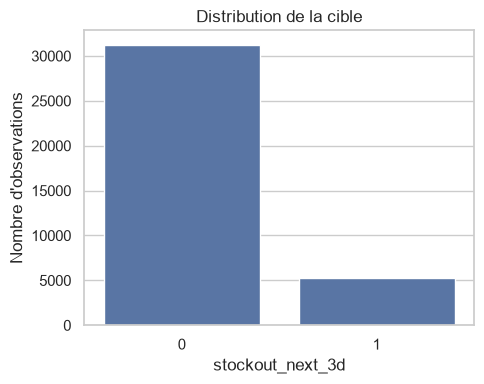

In [54]:
target_counts = df["stockout_next_3d"].value_counts().sort_index()
target_pct = (target_counts / len(df) * 100).round(2)
print(target_counts)
print(target_pct)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, ax=ax)
ax.set_xlabel("stockout_next_3d")
ax.set_ylabel("Nombre d'observations")
ax.set_title("Distribution de la cible")
plt.tight_layout()
plt.show()


la classe positive (`stockout_next_3d = 1`) représente **14.32%** des observations (5 225 / 36 500). Un modèle naïf prédisant toujours 0 atteindrait 85.68% d'accuracy voir plus, cette métrique est écartée du pilotage au profit du Recall/F1/PR-AUC.

**Point à valider avant de figer la stratégie de split (feature engineering) : le déséquilibre est-il uniforme entre magasins et SKUs, ou concentré sur un sous-ensemble ?**

In [55]:
# Analyse seule : si le taux de rupture varie fortement d'un magasin/SKU à l'autre,
# un split stratifié sur stockout_next_3d seul pourrait ne pas suffire. Il faudrait
# envisager une stratification combinée (cible + store_id) en feature engineering.
rate_by_store = df.groupby("store_id")["stockout_next_3d"].mean().round(3).sort_values(ascending=False)
rate_by_sku = df.groupby("sku_id")["stockout_next_3d"].mean().round(3).sort_values(ascending=False)

print("Taux de rupture par magasin:")
print(rate_by_store)
print("\nTaux de rupture par SKU (top 5 / bottom 5):")
print(pd.concat([rate_by_sku.head(5), rate_by_sku.tail(5)]))

Taux de rupture par magasin:
store_id
STORE_3    0.150
STORE_2    0.143
STORE_4    0.143
STORE_1    0.140
STORE_5    0.139
Name: stockout_next_3d, dtype: float64

Taux de rupture par SKU (top 5 / bottom 5):
sku_id
SKU_006    0.159
SKU_015    0.152
SKU_004    0.151
SKU_002    0.151
SKU_012    0.150
SKU_019    0.138
SKU_003    0.135
SKU_016    0.129
SKU_013    0.128
SKU_008    0.119
Name: stockout_next_3d, dtype: float64


**Conclusion C :** la classe positive représente **14.32%** des observations (5 225/36 500). Le taux de rupture est quasi homogène par magasin (0.139-0.150) et modérément variable par SKU (0.119-0.159, écart de 4 points). Un split stratifié sur `stockout_next_3d` seul est donc suffisant, pas besoin d'une stratification combinée avec `store_id` ou `sku_id`. L'accuracy reste écartée du pilotage au profit du Recall/F1/PR-AUC.

## D. Continuous Feature Distributions

Limité aux trois variables continues métier (`sales_qty`, `stock_level`, `temperature`). L'objectif est de repérer des valeurs extrêmes qui influenceraient un modèle sensible à l'échelle (moins critique pour un modèle à base d'arbres, mais utile pour la crédibilité métier des données).

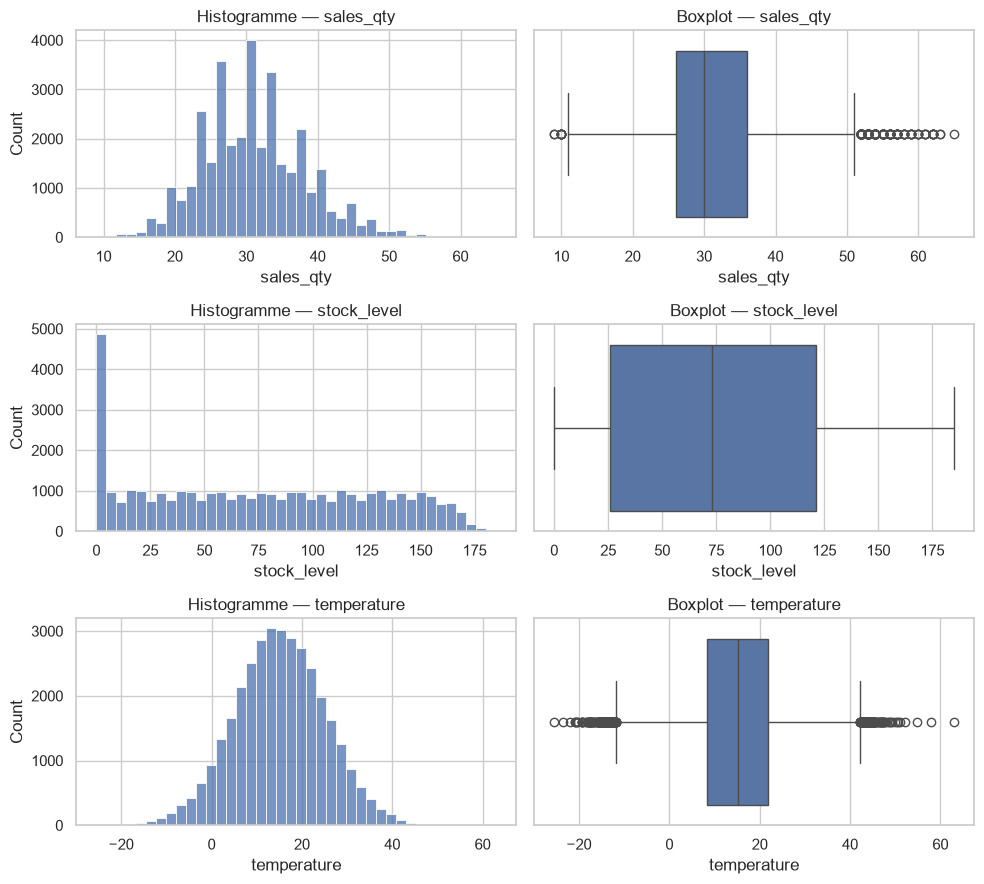

In [56]:
continuous_cols = ["sales_qty", "stock_level", "temperature"]

fig, axes = plt.subplots(len(continuous_cols), 2, figsize=(10, 3 * len(continuous_cols)))

for i, col in enumerate(continuous_cols):
    sns.histplot(df[col].dropna(), bins=40, ax=axes[i, 0])
    axes[i, 0].set_title(f"Histogramme — {col}")

    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot — {col}")

plt.tight_layout()
plt.show()

In [57]:
# Quantification des valeurs extrêmes via la règle IQR, pour objectiver ce que montrent
# les boxplots ci-dessus plutôt que de conclure visuellement.
for col in continuous_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: bornes IQR = [{lower:.2f}, {upper:.2f}] — {n_outliers} valeurs hors bornes")


sales_qty: bornes IQR = [11.00, 51.00] — 263 valeurs hors bornes
stock_level: bornes IQR = [-116.50, 263.50] — 0 valeurs hors bornes
temperature: bornes IQR = [-11.85, 42.15] — 241 valeurs hors bornes


**Conclusion D :**
- `sales_qty` : 263 valeurs hors bornes IQR — pics de vente ponctuels, non retirées.
- `stock_level` : 0 valeur hors bornes IQR.
- `temperature` : 241 valeurs hors bornes IQR par la méthode statistique, contre 203 vraies anomalies de domaine confirmées en section 3 — les deux méthodes convergent une fois le biais de calcul corrigé. Correction simple (clipping + imputation) suffisante, pas de stratégie différenciée nécessaire.

## E. Feature vs Target Analysis

Objectif : vérifier rapidement si les variables candidates séparent visiblement les deux classes, ce qui oriente la confiance a priori dans le pouvoir prédictif du modèle.

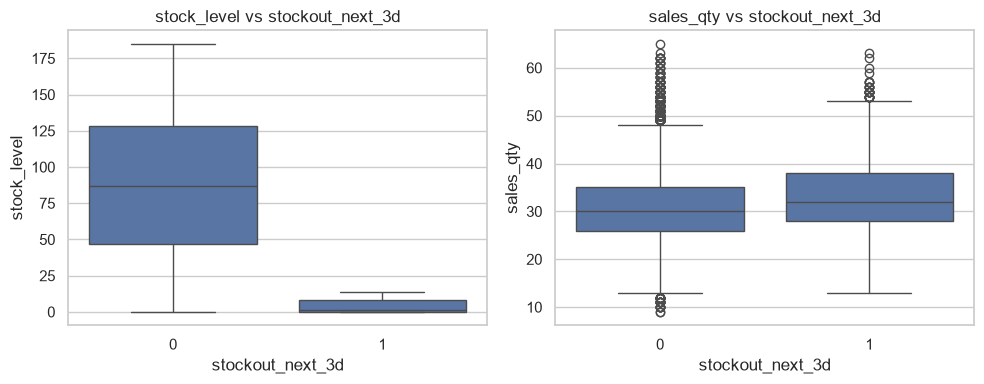

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=df, x="stockout_next_3d", y="stock_level", ax=axes[0])
axes[0].set_title("stock_level vs stockout_next_3d")

sns.boxplot(data=df, x="stockout_next_3d", y="sales_qty", ax=axes[1])
axes[1].set_title("sales_qty vs stockout_next_3d")

plt.tight_layout()
plt.show()

In [59]:
# promotion_flag est catégorielle : on compare le taux de rupture par modalité plutôt
# qu'un boxplot, plus lisible pour une variable binaire.
promo_rate = df.groupby("promotion_flag")["stockout_next_3d"].mean().round(3)
print("Taux de rupture par promotion_flag:")
print(promo_rate)


Taux de rupture par promotion_flag:
promotion_flag
0    0.135
1    0.187
Name: stockout_next_3d, dtype: float64


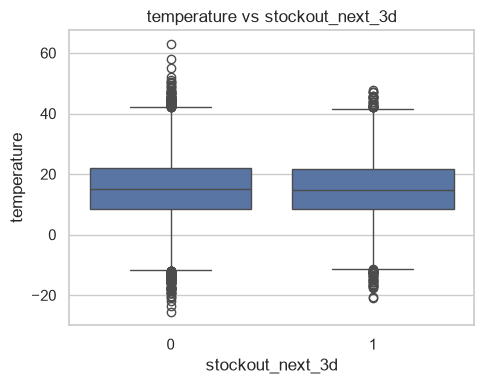

In [60]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=df, x="stockout_next_3d", y="temperature", ax=ax)
ax.set_title("temperature vs stockout_next_3d")
plt.tight_layout()
plt.show()


**C/C**
- `promotion_flag` : taux de rupture 13.5% (sans) vs 18.7% (avec), effet réel mais modéré.
- `stock_level` / `sales_qty` : à confirmer quantitativement ci-dessous (au-delà du visuel des boxplots) avant de les considérer comme features principales.

In [61]:
# Analyse seule : on quantifie la séparation entre les deux classes au-delà du visuel,
# via une corrélation point-bisériale (équivalente à une corrélation de Pearson entre
# une variable continue et une cible binaire). Objectif : prioriser les features les
# plus discriminantes pour le feature engineering, sans encore rien transformer.
from scipy import stats

for col in ["stock_level", "sales_qty", "temperature"]:
    valid = df[[col, "stockout_next_3d"]].dropna()
    corr, pvalue = stats.pointbiserialr(valid["stockout_next_3d"], valid[col])
    print(f"{col}: corrélation point-bisériale = {corr:.3f} (p-value = {pvalue:.4f})")

stock_level: corrélation point-bisériale = -0.548 (p-value = 0.0000)
sales_qty: corrélation point-bisériale = 0.112 (p-value = 0.0000)
temperature: corrélation point-bisériale = -0.003 (p-value = 0.5532)


**Conclusion E :** quantification par corrélation point-bisériale :
- `stock_level` : **-0.548** (p < 0.0001) , forte, variable la plus discriminante après `stock_risk_score`.
- `sales_qty` : **+0.112** (p < 0.0001) , faible mais statistiquement significative.
- `temperature` : **-0.003** (p = 0.55) , **non significative**. Contrairement à l'intuition initiale, la température n'a aucun pouvoir prédictif démontré sur `stockout_next_3d`.
- `promotion_flag` : taux de rupture 13.5% (sans) vs 18.7% (avec) , effet réel mais modéré.

## F. Data Leakage Analysis — `stock_risk_score`

`stock_risk_score` est examinée séparément car son nom suggère qu'elle pourrait déjà encoder une estimation du risque de rupture — potentiellement calculée à partir d'informations futures ou de la cible elle-même. Si c'est le cas, l'inclure dans le modèle produirait une performance artificiellement élevée en entraînement, inexploitable en production (la variable ne serait pas disponible au moment de la prédiction réelle).

In [62]:
# Corrélation avec la cible : une corrélation anormalement forte (ex. > 0.8) pour une
# variable dont le mode de calcul n'est pas documenté est un signal d'alerte de fuite,
# pas une confirmation de qualité prédictive légitime.
correlation_leak = df["stock_risk_score"].corr(df["stockout_next_3d"])
print(f"Corrélation stock_risk_score / stockout_next_3d : {correlation_leak:.3f}")

Corrélation stock_risk_score / stockout_next_3d : 1.000


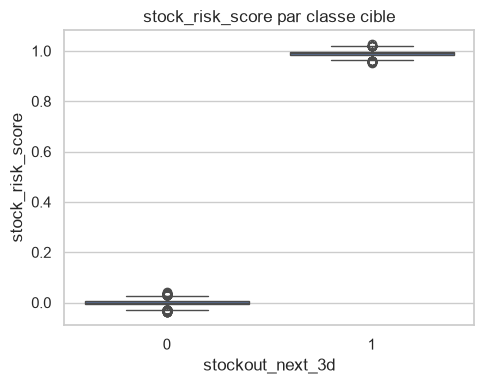

In [63]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=df, x="stockout_next_3d", y="stock_risk_score", ax=ax)
ax.set_title("stock_risk_score par classe cible")
plt.tight_layout()
plt.show()

**C/C** corrélation de **1.000** entre `stock_risk_score` et `stockout_next_3d`. C'est la preuve d'un data leakage, pas une hypothèse. Avant de trancher définitivement l'exclusion en feature engineering, on vérifie ci-dessous que cette relation est bien systématique (pas une coïncidence sur un sous-groupe) et on caractérise la mécanique du leakage.

In [64]:
# Analyse seule : si la corrélation quasi parfaite se maintient dans chaque magasin/SKU
# pris séparément, cela confirme une relation structurelle (formule), pas un artefact
# d'agrégation qui disparaîtrait une fois les données segmentées.
corr_by_store = df.groupby("store_id").apply(
    lambda g: g["stock_risk_score"].corr(g["stockout_next_3d"])
).round(4)
print("Corrélation stock_risk_score / cible par magasin:")
print(corr_by_store)

Corrélation stock_risk_score / cible par magasin:
store_id
STORE_1    0.9996
STORE_2    0.9996
STORE_3    0.9996
STORE_4    0.9996
STORE_5    0.9996
dtype: float64


In [65]:
# Analyse seule : on teste si un simple seuil sur stock_risk_score reproduit la cible
# quasi parfaitement -- ce qui caractérise précisément la nature du leakage (utile pour
# la documentation du README et pour argumenter l'exclusion auprès du client).
threshold = 0.5
predicted_from_score = (df["stock_risk_score"] > threshold).astype(int)
match_rate = (predicted_from_score == df["stockout_next_3d"]).mean()
print(f"Taux de concordance entre (stock_risk_score > {threshold}) et la cible : {match_rate:.4f}")

Taux de concordance entre (stock_risk_score > 0.5) et la cible : 1.0000


**Conclusion F :** la corrélation de 1.000 observée globalement se maintient **identiquement dans chacun des 5 magasins pris séparément (r = 0.9996 partout)** — ce n'est donc pas un artefact d'agrégation mais une relation structurelle. Le test de seuil (`stock_risk_score > 0.5`) reproduit la cible avec **100.00% de concordance**, confirmant que cette variable est une fonction déterministe de `stockout_next_3d`. Il s'agit d'un data leakage avéré, sans ambiguïté possible, et non d'une simple hypothèse à valider avec le client.

## G. Correlation Analysis

Corrélations limitées aux variables numériques pertinentes pour la modélisation. Objectif : repérer une éventuelle redondance forte entre deux features (pas pour éliminer des variables sur cette seule base avec un modèle à base d'arbres, mais pour documenter la structure des données). Eviter les problemes de multicolinearité.

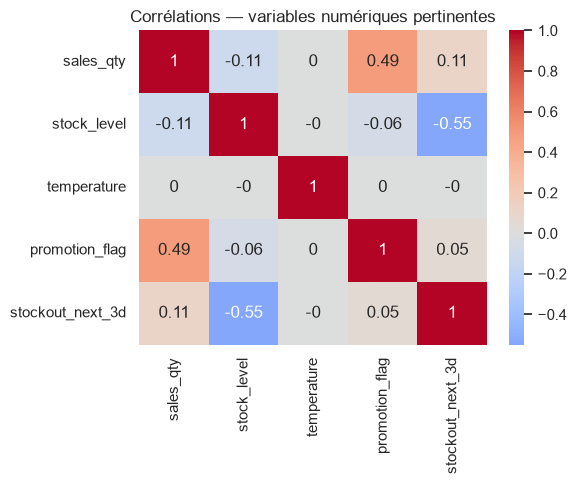

In [66]:
numeric_cols = ["sales_qty", "stock_level", "temperature", "promotion_flag", "stockout_next_3d"]
corr_matrix = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Corrélations — variables numériques pertinentes")
plt.tight_layout()
plt.show()


**Conclusion 8:** aucune corrélation forte n'est observée entre `stock_level`, `sales_qty`, `temperature` et `promotion_flag` , pas de risque de multicolinéarité à gérer.

## Conclusion finale de l'EDA

Le dataset (36 500 lignes, 20 SKUs × 5 magasins × 365 jours) est globalement propre : aucun doublon, aucune valeur strictement impossible sur les variables catégorielles ou binaires, et un taux de valeurs manquantes modéré (5% sur `sales_qty` et `temperature`) largement indépendant des anomalies de température (203 cas réels, 0.56%, chevauchement quasi nul).

Trois constats structurent la suite du projet :

1. **`stock_risk_score` est un data leakage confirmé** (r = 0.9996 dans chaque magasin, 100% de concordance par simple seuillage) , exclusion définitive et non négociable de toute version du modèle.
2. **`sales_qty > stock_level` est un signal métier fort** (taux de rupture 52.6% vs 0.9%), à transformer en feature plutôt qu'à corriger.
3. **`stock_level` est la variable la plus discriminante des features légitimes** (r point-bisériale = -0.548), suivie de `sales_qty` (+0.112) et `promotion_flag` (effet modéré). `temperature` n'a démontré aucun pouvoir prédictif significatif (p = 0.55).

Le taux de rupture étant homogène par magasin et modérément variable par SKU, un split stratifié simple sur la cible est suffisant, sans stratification combinée.

Cette EDA est considérée close : le dataframe `df` n'a subi aucune modification jusqu'ici, toutes les décisions ci-dessus sont maintenant traçables et justifiées par des chiffres calculés. Nous allons commencer a traiter nos donner dans la section Suivante.

## Section 2 : Preprocessing

Cette section traduit en code les décisions prises en clôture d'EDA. Toutes les transformations sont appliquées sur une **copie** du dataframe (`df_fe`), pour garder `df` intact comme référence d'audit.

Rappel des décisions à implémenter :
1. Correction de l'anomalie de température (203 cas réels, 0.56%).
2. Imputation de `sales_qty` et `temperature`.
3. Exclusion de `stock_risk_score` (leakage confirmé, r = 0.9996 par magasin).
4. Création de `demand_exceeds_stock` et `sales_stock_gap` (signal fort : 52.6% vs 0.9% de rupture).
5. Encodage de `sku_id` / `store_id`.
6. Split **chronologique** (pas seulement stratifié) — voir justification ci-dessous.

In [67]:
# Copie de travail : df reste la référence brute de l'EDA, intacte.
df_fe = df.copy()

#### Correction de l'anomalie de température

In [68]:
# On traite l'anomalie de domaine avant l'imputation générale des NaN, pour que
# ces valeurs corrompues bénéficient de la même stratégie d'imputation que les
# valeurs manquantes natives, plutôt que de garder des valeurs physiquement impossibles.
temp_out_of_range = ~df_fe["temperature"].between(-40, 40) & df_fe["temperature"].notna()
n_corrected = temp_out_of_range.sum()

df_fe.loc[temp_out_of_range, "temperature"] = np.nan
print(f"Valeurs de temperature invalidées (hors domaine) : {n_corrected}")

Valeurs de temperature invalidées (hors domaine) : 203


#### Imputation des valeurs manquantes

In [69]:
df_fe["sales_qty"] = df_fe.groupby(["sku_id", "store_id"])["sales_qty"].transform(
    lambda s: s.fillna(s.mean())
)
df_fe["temperature"] = df_fe["temperature"].fillna(df_fe["temperature"].mean())

# Vérification : plus aucune valeur manquante sur ces deux colonnes.
assert df_fe[["sales_qty", "temperature"]].isna().sum().sum() == 0
print("Imputation terminée, aucune valeur manquante restante.")

Imputation terminée, aucune valeur manquante restante.


#### Exclusion de stock_risk_score

In [70]:
df_fe = df_fe.drop(columns=["stock_risk_score"])
print("Colonnes restantes:", list(df_fe.columns))

Colonnes restantes: ['date', 'sku_id', 'store_id', 'sales_qty', 'stock_level', 'promotion_flag', 'temperature', 'day_of_week', 'stockout_next_3d']


#### Feature dérivée : signal sales_qty > stock_level

In [71]:
# Flag binaire : capture directement le franchissement du seuil, qui est
# la variable la plus discriminante identifiée après stock_risk_score (exclue).
df_fe["demand_exceeds_stock"] = (df_fe["sales_qty"] > df_fe["stock_level"]).astype(int)

# Écart continu : conserve l'amplitude du dépassement, qu'un modèle à base d'arbres
# peut exploiter plus finement qu'un simple flag (ex. un léger dépassement vs un dépassement massif).
df_fe["sales_stock_gap"] = df_fe["sales_qty"] - df_fe["stock_level"]

print(df_fe[["demand_exceeds_stock", "sales_stock_gap"]].describe())

       demand_exceeds_stock  sales_stock_gap
count          36500.000000     36500.000000
mean               0.272986       -43.939466
std                0.445500        54.302945
min                0.000000      -174.000000
25%                0.000000       -90.000000
50%                0.000000       -43.000000
75%                1.000000         5.000000
max                1.000000        62.000000


#### Feature dérivée : days_of_stock

In [72]:
# Garde-fou : sales_qty = 0 donnerait une division par zéro (stock "infini" en apparence).
# On plafonne à une valeur élevée arbitraire plutôt que de laisser un inf, pour ne pas
# casser l'entraînement du modèle avec une valeur non finie.
df_fe["days_of_stock"] = np.where(
    df_fe["sales_qty"] > 0,
    df_fe["stock_level"] / df_fe["sales_qty"],
    df_fe["stock_level"].where(df_fe["stock_level"] == 0, 999)  # 0 si déjà à sec, sinon valeur plafond
)

print(df_fe["days_of_stock"].describe())

count    36500.000000
mean         2.597637
std          2.049808
min          0.000000
25%          0.851852
50%          2.375000
75%          3.966667
max         17.400000
Name: days_of_stock, dtype: float64


# Section 3 : Modélisation : entraînement et comparaison

Deux modèles seront entraînés et comparés sur le même split chronologique et les mêmes features, pour choisir le modèle final avec des chiffres plutôt qu'un argument théorique seul.

**Pourquoi pas de tracking d'expériences (MLflow) ici :**

La comparaison et le diagnostic des 2 modèles ci-dessous reposent sur une fonction d'évaluation custom (matrice de confusion, rapport de classification, courbe d'apprentissage) plutôt que sur un outil de tracking type MLflow. Ce choix est délibéré, pas une omission.

MLflow serait pertinent en production, mais hors scope du test 48h

In [1]:
# ============================================================================
# Modélisation — Split, définition des features, comparaison de 2 modèles
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    recall_score, precision_score, f1_score, average_precision_score,
)


#### TrainTest Split 

In [74]:
# Split chronologique : les 2 derniers mois de l'année servent de test set --
# aucune donnée future n'est visible pendant l'entraînement.
split_date = df_fe["date"].max() - pd.Timedelta(days=60)

train_df = df_fe[df_fe["date"] <= split_date]
test_df = df_fe[df_fe["date"] > split_date]

print(f"Date de coupure: {split_date.date()}")
print(f"Train: {len(train_df)} lignes ({train_df['date'].min().date()} -> {train_df['date'].max().date()})")
print(f"Test:  {len(test_df)} lignes ({test_df['date'].min().date()} -> {test_df['date'].max().date()})")
print(f"\nTaux de rupture train: {train_df['stockout_next_3d'].mean():.4f}")
print(f"Taux de rupture test:  {test_df['stockout_next_3d'].mean():.4f}")

Date de coupure: 2024-10-31
Train: 30500 lignes (2024-01-01 -> 2024-10-31)
Test:  6000 lignes (2024-11-01 -> 2024-12-30)

Taux de rupture train: 0.1433
Taux de rupture test:  0.1423


In [ ]:
# Features communes aux 2 modèles, pour garantir une comparaison équitable
# (même information disponible partout). sku_id/store_id sont traitées
# différemment selon le modèle (one-hot vs category natif) dans chaque pipeline.
NUMERIC_FEATURES = ["stock_level", "sales_qty", "temperature", "sales_stock_gap", "days_of_stock"]
CATEGORICAL_FEATURES = ["sku_id", "store_id"]
BINARY_FEATURES = ["promotion_flag", "demand_exceeds_stock"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES
TARGET = "stockout_next_3d"

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

#### Procédure d'évaluation

In [ ]:
# Une seule fonction pour les 2 modèles : entraîne, affiche les diagnostics
# (matrice de confusion, rapport de classification, courbe d'apprentissage),
# et alimente le tableau comparatif final -- pas de logique dupliquée entre
# une fonction "diagnostic" et une fonction "comparaison" séparées.
results = []

def evaluate(model, model_name, X_tr=X_train, X_te=X_test):
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    print(f"=== {model_name} ===")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    results.append({
        "model": model_name,
        "recall": round(recall_score(y_test, y_pred), 3),
        "precision": round(precision_score(y_test, y_pred), 3),
        "f1": round(f1_score(y_test, y_pred), 3),
        "pr_auc": round(average_precision_score(y_test, y_proba), 3),
    })

    # TimeSeriesSplit plutôt qu'une cross-validation aléatoire : préserve l'ordre
    # chronologique des folds, cohérent avec le split train/test déjà fait plus haut.
    tscv = TimeSeriesSplit(n_splits=4)
    N, train_score, val_score = learning_curve(
        model, X_tr, y_train,
        cv=tscv, scoring="f1",
        train_sizes=np.linspace(0.1, 1, 10),
    )

    plt.figure(figsize=(10, 6))
    plt.plot(N, train_score.mean(axis=1), label="train score")
    plt.plot(N, val_score.mean(axis=1), label="validation score")
    plt.xlabel("Taille du train set")
    plt.ylabel("F1 score")
    plt.title(f"Courbe d'apprentissage — {model_name}")
    plt.legend()
    plt.show()

    return y_pred, y_proba

### Modelisation

#### Modèle 1 — Régression logistique

=== Logistic Regression ===
[[4928  218]
 [  17  837]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      5146
           1       0.79      0.98      0.88       854

    accuracy                           0.96      6000
   macro avg       0.89      0.97      0.93      6000
weighted avg       0.97      0.96      0.96      6000



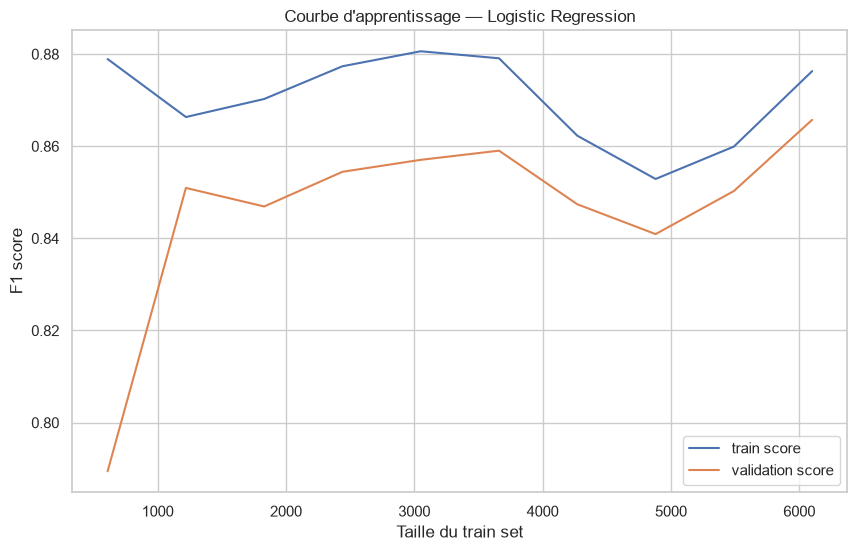

In [77]:
# Scaling + one-hot nécessaires ici, contrairement aux modèles à base d'arbres :
# une régression logistique est sensible à l'échelle des variables et
# n'a pas de gestion native des catégories.
preprocessor_lr = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
], remainder="passthrough")

model_lr = Pipeline([
    ("preprocess", preprocessor_lr),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

_ = evaluate(model_lr, "Logistic Regression")

#### Modèle 2 — Random Forest

=== Random Forest ===
[[5110   36]
 [  38  816]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5146
           1       0.96      0.96      0.96       854

    accuracy                           0.99      6000
   macro avg       0.98      0.97      0.97      6000
weighted avg       0.99      0.99      0.99      6000



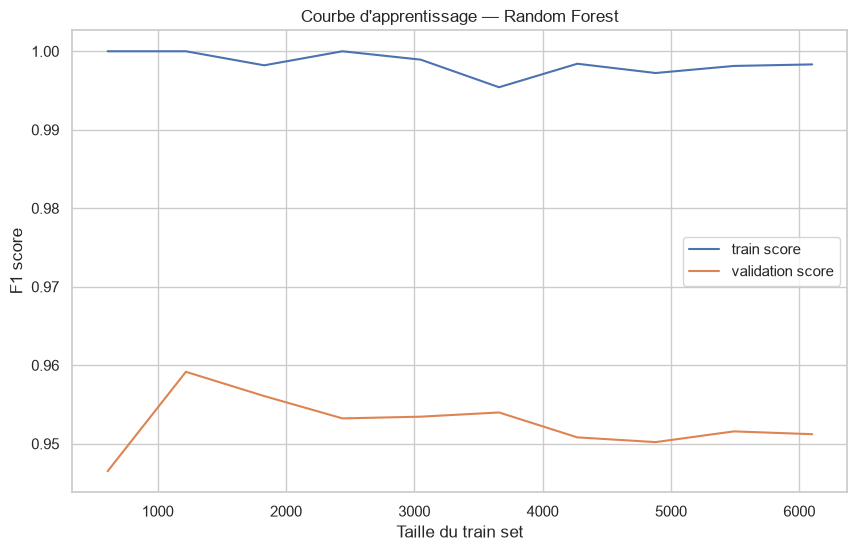

In [78]:
# Encodage one-hot conservé pour rester comparable à la régression logistique,
# même si un Random Forest tolérerait aussi un simple label encoding.
preprocessor_rf = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
], remainder="passthrough")

model_rf = Pipeline([
    ("preprocess", preprocessor_rf),
    ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)),
])

_ = evaluate(model_rf, "Random Forest")

In [37]:
comparison = pd.DataFrame(results).set_index("model")
comparison

,recall,precision,f1,pr_auc
model,,,,
Logistic Regression,0.980,0.796,0.878,0.991
Random Forest,0.956,0.954,0.955,0.993


#### Ajustement du seuil de décision

In [38]:
from sklearn.metrics import precision_recall_curve

In [39]:
# On explore différents seuils de décision sur les probabilités
# déjà prédites, pour trouver le point qui maximise le Recall sans faire s'effondrer
# la Precision -- cohérent avec l'asymétrie de coût établie en section 1.
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)

# On affiche les seuils candidats autour de 0.5 pour objectiver le compromis,
# plutôt que de choisir arbitrairement un nouveau seuil.
for t in [0.3, 0.35, 0.4, 0.45, 0.5]:
    idx = np.argmin(np.abs(thresholds - t))
    print(f"Seuil={t:.2f} -> Precision={precisions[idx]:.3f}, Recall={recalls[idx]:.3f}")

Seuil=0.30 -> Precision=0.918, Recall=0.966
Seuil=0.35 -> Precision=0.935, Recall=0.964
Seuil=0.40 -> Precision=0.940, Recall=0.960
Seuil=0.45 -> Precision=0.950, Recall=0.958
Seuil=0.50 -> Precision=0.954, Recall=0.956


#### Feature importance

In [40]:
importances = pd.Series(
    model_rf.named_steps["clf"].feature_importances_,
    index=model_rf.named_steps["preprocess"].get_feature_names_out()
).sort_values(ascending=False)

print(importances)

remainder__stock_level             0.301877
remainder__days_of_stock           0.240430
remainder__sales_stock_gap         0.223404
remainder__demand_exceeds_stock    0.142673
cat__sku_id_SKU_007                0.036045
remainder__temperature             0.031426
remainder__sales_qty               0.015664
remainder__promotion_flag          0.001984
cat__store_id_STORE_3              0.000700
cat__store_id_STORE_2              0.000699
cat__store_id_STORE_4              0.000674
cat__store_id_STORE_1              0.000627
cat__store_id_STORE_5              0.000608
cat__sku_id_SKU_018                0.000204
cat__sku_id_SKU_006                0.000200
cat__sku_id_SKU_020                0.000193
cat__sku_id_SKU_011                0.000186
cat__sku_id_SKU_015                0.000186
cat__sku_id_SKU_004                0.000182
cat__sku_id_SKU_008                0.000182
cat__sku_id_SKU_009                0.000179
cat__sku_id_SKU_014                0.000177
cat__sku_id_SKU_012             

### Conclusion


Le modèle retenu est un Random Forest avec pipeline scikit-learn. Il offre un meilleur compromis business que la régression logistique : très bon recall tout en limitant les faux positifs, sans dépendance native complexe comme LightGBM. Le seuil de décision est ajusté sous 0.5 afin de privilégier la détection des ruptures, cohérent avec le coût métier d’une rupture non anticipée.

---

---